##Problem 1 - Check the running time of a 2-layer MLP on 100 samples of size 1000 on the GPU and CPU, and measure the speedup.

In [1]:
import torch
import torch.nn as nn
import time

In [2]:
class TwoLayerMLP(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(TwoLayerMLP,self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size, output_size)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

In [3]:
num_samples = 100
input_size = 1000
hidden_size = 512
output_size = 10

X = torch.randn(num_samples, input_size)

In [4]:
X

tensor([[ 0.6414,  0.5795,  0.2477,  ...,  0.3165,  0.3479,  2.0207],
        [-1.2664, -0.7116,  0.1382,  ...,  1.6874,  1.3314, -0.8239],
        [-1.6485, -0.8827,  0.6553,  ..., -0.0933, -0.2620, -0.2411],
        ...,
        [-0.9177,  2.4718,  0.5618,  ...,  0.1753,  0.1537,  1.4736],
        [ 0.1011,  1.0481,  1.2155,  ..., -1.5731,  0.6843,  0.8012],
        [-0.6873,  0.0253, -0.6040,  ...,  1.3971, -0.8318, -0.9473]])

In [5]:
cpu_device = torch.device("cpu")

model_cpu = TwoLayerMLP(input_size,hidden_size, output_size).to(cpu_device)
X_cpu = X.to(cpu_device)

In [6]:
start = time.time()

for _ in range(100):
  output = model_cpu(X_cpu)

cpu_time = time.time()-start
print(f"CPU time : {cpu_time}")

CPU time : 0.26316404342651367


In [7]:
gpu_available = torch.cuda.is_available()
print(gpu_available)

True


In [8]:
if gpu_available:
  gpu_device = torch.device("cuda")

  model_gpu = TwoLayerMLP(input_size,hidden_size, output_size).to(gpu_device)
  X_gpu = X.to(gpu_device)

  for _ in range(10):
    output = model_gpu(X_gpu)

  torch.cuda.synchronize()
  start_time = time.time()

  for _ in range(100):
    output = model_gpu(X_gpu)

  torch.cuda.synchronize()
  gpu_time = time.time()-start_time
  print(f"GPU time : {gpu_time}")

GPU time : 0.030085325241088867


In [9]:
if gpu_available:
  print(f"Speedup (CPU/GPU) : {cpu_time / gpu_time}")

Speedup (CPU/GPU) : 8.747256056487593


##Problem 2 - Train a CNN model and save it

In [10]:
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

In [12]:
train_dataset = torchvision.datasets.MNIST(root = "./data", download=True, train = True, transform = transform)
test_dataset = torchvision.datasets.MNIST(root = "./data", download=True, train = False, transform = transform)

train_loader = DataLoader(train_dataset, shuffle=True, batch_size = 64)

In [13]:
class SimpleCNN(nn.Module):
  def __init__(self):
    super(SimpleCNN,self).__init__()
    self.conv1 = nn.Conv2d(1,16,3,1)
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(2)
    self.fc1 = nn.Linear(16*13*13,10)

  def forward(self,x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.pool(x)
    x = torch.flatten(x,1)
    x = self.fc1(x)
    return x

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [15]:
epochs = 3

for epoch in range(epochs):
  running_loss = 0

  for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  print(f"Epoch:{epoch+1}, Loss:{running_loss}")

Epoch:1, Loss:210.11048744432628
Epoch:2, Loss:79.13778451643884
Epoch:3, Loss:60.49063636944629


In [16]:
torch.save(model.state_dict(), "cnn_model.pth")
print("Model saved successfully")

Model saved successfully


##Problem 3 - Load the pretrained model and perform inference

In [17]:
model_loaded = SimpleCNN().to(device)
model_loaded.load_state_dict(torch.load("cnn_model.pth", map_location=device))

<All keys matched successfully>

In [18]:
import matplotlib.pyplot as plt

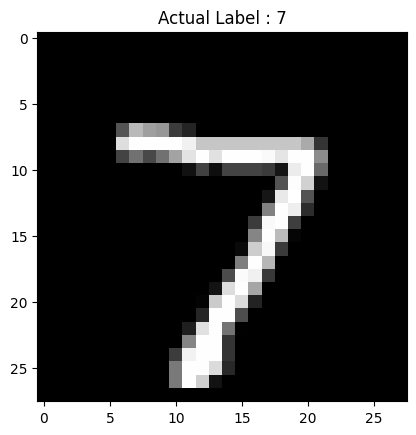

In [19]:
test_loader = DataLoader(test_dataset, batch_size=1)
images,labels = next(iter(test_loader))
images = images.to(device)

img = images[0].cpu()
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Actual Label : {labels[0].item()}")
plt.show()

In [20]:
model_loaded.eval()

with torch.no_grad():
  outputs = model_loaded(images)
  _,predicted = torch.max(outputs,1)

print("Predicted Label : ",predicted.item())
print("Actual Label : ",labels.item())

Predicted Label :  7
Actual Label :  7


##Problem 4 - Transfer Learning

In [21]:
from torch.utils.data import Subset

In [22]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

In [23]:
train_dataset = torchvision.datasets.CIFAR100(root="./data", download=True, train=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR100(root="./data", download=True, train=False, transform=transform)

In [24]:
selected_classes_10 = range(10)

train_idx = [i for i,(_,label) in enumerate(train_dataset) if label in selected_classes_10]
test_idx = [i for i,(_,label) in enumerate(test_dataset) if label in selected_classes_10]

train_subset = Subset(train_dataset, train_idx)
test_subset = Subset(test_dataset, test_idx)

In [25]:
train_loader = DataLoader(train_subset, shuffle=True, batch_size=64)
test_loader = DataLoader(test_subset, batch_size=64)

In [26]:
from torch.nn.modules.linear import Linear
class CNN(nn.Module):
  def __init__(self, num_classes=10):
    super(CNN,self).__init__()

    self.features = nn.Sequential(
        nn.Conv2d(3,32,3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(32,64,3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64,128,3,padding=1),
        nn.ReLU(),

        nn.Conv2d(128,128,3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )

    self.classifier = nn.Sequential(
        nn.Linear(128*4*4,512),
        nn.ReLU(),

        nn.Linear(512,256),
        nn.ReLU(),

        nn.Linear(256,128),
        nn.ReLU(),

        nn.Linear(128,num_classes)
      )

  def forward(self,x):
    x = self.features(x)
    x = torch.flatten(x,1)
    x = self.classifier(x)
    return x

In [27]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [28]:
def evaluate(loader,model):
  model.eval()
  correct,total = 0,0

  with torch.no_grad():
    for images,labels in loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      _,predicted = torch.max(outputs,1)

      total += labels.size(0)
      correct += (predicted == labels).sum().item()

  return correct/total * 100

In [29]:
epochs = 10

for epoch in range(epochs):
  running_loss = 0
  correct, total = 0,0

  for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    loss = criterion(outputs,labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    _, predicted = torch.max(outputs,1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  train_acc = correct / total * 100
  test_acc = evaluate(test_loader,model)

  print(f"Epoch:{epoch+1}, Loss:{running_loss:.4f}, Training Accuracy:{train_acc}%, Test Accuracy:{test_acc}%")

Epoch:1, Loss:161.5602, Training Accuracy:25.1%, Test Accuracy:32.6%
Epoch:2, Loss:130.8247, Training Accuracy:41.339999999999996%, Test Accuracy:42.699999999999996%
Epoch:3, Loss:113.3901, Training Accuracy:48.96%, Test Accuracy:46.1%
Epoch:4, Loss:105.2195, Training Accuracy:53.36%, Test Accuracy:53.900000000000006%
Epoch:5, Loss:92.7204, Training Accuracy:59.019999999999996%, Test Accuracy:54.900000000000006%
Epoch:6, Loss:85.3509, Training Accuracy:62.63999999999999%, Test Accuracy:61.0%
Epoch:7, Loss:77.2552, Training Accuracy:67.10000000000001%, Test Accuracy:59.199999999999996%
Epoch:8, Loss:72.8541, Training Accuracy:68.28%, Test Accuracy:64.2%
Epoch:9, Loss:61.6713, Training Accuracy:73.24000000000001%, Test Accuracy:65.9%
Epoch:10, Loss:53.0661, Training Accuracy:76.48%, Test Accuracy:65.60000000000001%


In [30]:
torch.save(model.state_dict(),"cnn10.pth")

In [31]:
inf_model = CNN(num_classes=10).to(device)
inf_model.load_state_dict(torch.load("cnn10.pth"))

<All keys matched successfully>

In [32]:
inf_model.eval()

images,labels = next(iter(test_loader))

with torch.no_grad():
  outputs = inf_model(images.to(device))
  _,predicted = torch.max(outputs,1)

print(f"Predicted Label : {predicted[0].item()}")
print(f"Actual Label : {labels[0].item()}")


Predicted Label : 0
Actual Label : 0


In [33]:
selected_classes_15 = list(range(15))

In [34]:
train_idx = [i for i,(_,labels) in enumerate(train_dataset) if labels in selected_classes_15]
test_idx = [i for i,(_,labels) in enumerate(test_dataset) if labels in selected_classes_15]

In [35]:
train_subset = Subset(train_dataset, train_idx)
test_subset = Subset(test_dataset, test_idx)

In [36]:
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=64)

In [37]:
model_10 = CNN(num_classes=10).to(device)
model_10.load_state_dict(torch.load("cnn10.pth"))

<All keys matched successfully>

In [38]:
for param in model_10.features[:6].parameters():
  param.requires_grad = False

In [39]:
model_10.classifier[-1] = nn.Linear(128,15)
model_10 = model_10.to(device)

In [40]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_10.parameters()), lr=0.0005)

In [41]:
epochs = 15

for epoch in range(epochs):
  running_loss = 0
  correct, total = 0,0

  for images,labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model_10(images)
    loss = criterion(outputs,labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    _, predicted = torch.max(outputs,1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

  train_acc = correct / total * 100
  test_acc = evaluate(test_loader,model_10)

  print(f"Epoch:{epoch+1}, Loss:{running_loss:.4f}, Training Accuracy:{train_acc:.2f}%, Test Accuracy:{test_acc:.2f}%")

Epoch:1, Loss:187.0479, Training Accuracy:48.85%, Test Accuracy:52.53%
Epoch:2, Loss:127.7334, Training Accuracy:63.81%, Test Accuracy:55.13%
Epoch:3, Loss:108.5573, Training Accuracy:68.97%, Test Accuracy:55.07%
Epoch:4, Loss:94.0024, Training Accuracy:73.63%, Test Accuracy:57.73%
Epoch:5, Loss:78.7432, Training Accuracy:77.28%, Test Accuracy:57.93%
Epoch:6, Loss:65.1262, Training Accuracy:81.32%, Test Accuracy:58.60%
Epoch:7, Loss:52.4505, Training Accuracy:85.43%, Test Accuracy:58.40%
Epoch:8, Loss:39.8784, Training Accuracy:89.24%, Test Accuracy:59.07%
Epoch:9, Loss:28.8455, Training Accuracy:92.40%, Test Accuracy:58.93%
Epoch:10, Loss:23.3562, Training Accuracy:93.69%, Test Accuracy:58.27%
Epoch:11, Loss:14.8240, Training Accuracy:96.43%, Test Accuracy:58.20%
Epoch:12, Loss:9.9876, Training Accuracy:98.04%, Test Accuracy:57.93%
Epoch:13, Loss:12.0601, Training Accuracy:97.23%, Test Accuracy:57.20%
Epoch:14, Loss:9.0608, Training Accuracy:97.92%, Test Accuracy:59.20%
Epoch:15, Loss